# VAD-Matched Control-Term Candidates

Exploratory candidate generation for possible non-therapy-speak comparator terms near the affective profile of `adhd` and `autism` in the NRC-VAD lexicon.

This notebook is intentionally a first-pass screen rather than a final baseline selector. VAD proximity can identify affectively similar words, but it does not by itself guarantee nounhood, discourse comparability, non-clinical status, or suitable corpus frequency.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

ROOT = Path("..")
LEXICON_PATH = (
    ROOT
    / "src/data_sources/NRC-VAD_lexicon/NRC-VAD-Lexicon-v2.1/NRC-VAD-Lexicon-v2.1.txt"
)
TARGET_TERMS = ["adhd", "autism"]
VAD_COLUMNS = ["valence", "arousal", "dominance"]
STRICT_TOLERANCE = 0.05
BROAD_TOLERANCE = 0.10

lexicon = pd.read_csv(LEXICON_PATH, sep="\t")
assert set(["term", *VAD_COLUMNS]).issubset(lexicon.columns)
lexicon.head()

,term,valence,arousal,dominance
0,a battery,0.134,-0.298,-0.096
1,a bit,-0.096,-0.264,-0.214
2,a bunch,0.088,-0.350,-0.068
3,a cappella,0.134,-0.116,-0.200
4,a couple,0.266,-0.110,0.090


## 1. Target centroid

The two target terms are averaged into a single reference point in VAD space. Candidate controls are then compared with that centroid rather than with either target in isolation.

In [4]:
target_profile = (
    lexicon.loc[lexicon["term"].isin(TARGET_TERMS), ["term", *VAD_COLUMNS]]
    .sort_values("term")
    .reset_index(drop=True)
)
target_centroid = target_profile[VAD_COLUMNS].mean()

print("Target terms")
display(target_profile)
print("Aggregated target centroid")
display(target_centroid.to_frame("value"))

Target terms


,term,valence,arousal,dominance
0,adhd,-0.484,-0.054,-0.072
1,autism,-0.530,0.000,-0.106


Aggregated target centroid


,value
valence,-0.507
arousal,-0.027
dominance,-0.089


## 2. Candidate-generation rule

- `±0.05` on all three VAD dimensions is treated as a strict inner band.
- `±0.10` is treated as the broader search space.
- Euclidean distance to the centroid ranks candidates inside either band.
- Lexical-shape flags are retained because multiword expressions and non-alphabetic forms are usually poor direct comparators for the target nouns.

In [5]:
candidate_frame = lexicon.copy()
candidate_frame["distance_to_centroid"] = (
    (candidate_frame[VAD_COLUMNS] - target_centroid).pow(2).sum(axis=1).pow(0.5)
)
candidate_frame["within_0_05"] = (
    (candidate_frame[VAD_COLUMNS] - target_centroid).abs().le(STRICT_TOLERANCE).all(axis=1)
)
candidate_frame["within_0_10"] = (
    (candidate_frame[VAD_COLUMNS] - target_centroid).abs().le(BROAD_TOLERANCE).all(axis=1)
)
candidate_frame["is_target"] = candidate_frame["term"].isin(TARGET_TERMS)
candidate_frame["single_token_alpha"] = candidate_frame["term"].str.fullmatch(r"[A-Za-z]+")
candidate_frame["multiword"] = candidate_frame["term"].str.contains(r"\s", regex=True)

band_summary = pd.DataFrame(
    {
        "band": ["within_0_05", "within_0_10"],
        "term_count": [candidate_frame["within_0_05"].sum(), candidate_frame["within_0_10"].sum()],
        "single_token_alpha_count": [
            candidate_frame.loc[candidate_frame["within_0_05"], "single_token_alpha"].sum(),
            candidate_frame.loc[candidate_frame["within_0_10"], "single_token_alpha"].sum(),
        ],
    }
)
band_summary

,band,term_count,single_token_alpha_count
0,within_0_05,25,10
1,within_0_10,152,84


In [6]:
DISPLAY_COLUMNS = [
    "term",
    *VAD_COLUMNS,
    "distance_to_centroid",
    "single_token_alpha",
    "multiword",
    "is_target",
]

strict_candidates = (
    candidate_frame.loc[candidate_frame["within_0_05"], DISPLAY_COLUMNS]
    .sort_values(["distance_to_centroid", "term"])
    .reset_index(drop=True)
)
broad_candidates = (
    candidate_frame.loc[candidate_frame["within_0_10"], DISPLAY_COLUMNS]
    .sort_values(["distance_to_centroid", "term"])
    .reset_index(drop=True)
)

print("Strict inner band: ±0.05")
display(strict_candidates)
print("Broader search space: ±0.10")
display(broad_candidates.head(75))

Strict inner band: ±0.05


,term,valence,arousal,dominance,distance_to_centroid,single_token_alpha,multiword,is_target
0,recluse,-0.520,-0.020,-0.108,0.024062,True,False,False
1,red state,-0.516,-0.036,-0.066,0.026287,False,True,False
2,pour out,-0.500,0.000,-0.096,0.028758,False,True,False
3,surrender to,-0.500,0.000,-0.104,0.031670,False,True,False
4,drag on,-0.516,-0.064,-0.094,0.038406,False,True,False
5,adhd,-0.484,-0.054,-0.072,0.039332,True,False,True
6,autism,-0.530,0.000,-0.106,0.039332,True,False,True
7,cold blood,-0.482,0.000,-0.072,0.040534,False,True,False
8,oy vey,-0.518,-0.068,-0.096,0.043023,False,True,False
9,incongruously,-0.519,0.000,-0.056,0.044294,True,False,False


Broader search space: ±0.10


,term,valence,arousal,dominance,distance_to_centroid,single_token_alpha,multiword,is_target
0,recluse,-0.520,-0.020,-0.108,0.024062,True,False,False
1,red state,-0.516,-0.036,-0.066,0.026287,False,True,False
2,pour out,-0.500,0.000,-0.096,0.028758,False,True,False
3,surrender to,-0.500,0.000,-0.104,0.031670,False,True,False
4,drag on,-0.516,-0.064,-0.094,0.038406,False,True,False
5,adhd,-0.484,-0.054,-0.072,0.039332,True,False,True
6,autism,-0.530,0.000,-0.106,0.039332,True,False,True
7,cold blood,-0.482,0.000,-0.072,0.040534,False,True,False
8,oy vey,-0.518,-0.068,-0.096,0.043023,False,True,False
9,incongruously,-0.519,0.000,-0.056,0.044294,True,False,False


## 3. Noun-oriented review pool

The NRC-VAD lexicon does not provide part-of-speech labels. For a lightweight, dependency-free first pass, the notebook narrows the review pool to single-token alphabetic entries and excludes the target terms themselves. This is **not** a noun classifier; it simply removes many obvious idioms and phrasal forms before manual review.

If a later pass needs automated noun evidence, add a separate lexical-resource check such as WordNet noun senses or POS tagging with a model already validated for this project. That should remain a supporting signal, not a substitute for substantive review.

In [7]:
review_pool = (
    broad_candidates.loc[
        broad_candidates["single_token_alpha"] & ~broad_candidates["is_target"],
        ["term", *VAD_COLUMNS, "distance_to_centroid"],
    ]
    .sort_values(["distance_to_centroid", "term"])
    .reset_index(drop=True)
)

print(f"Single-token alphabetic review pool within ±0.10: {len(review_pool)} terms")
review_pool.head(100)

Single-token alphabetic review pool within ±0.10: 82 terms


,term,valence,arousal,dominance,distance_to_centroid
0,recluse,-0.520,-0.020,-0.108,0.024062
1,incongruously,-0.519,0.000,-0.056,0.044294
2,stoppage,-0.552,-0.018,-0.110,0.050468
3,unceremonious,-0.524,0.000,-0.048,0.051952
4,crass,-0.554,-0.020,-0.068,0.051952
5,overlarge,-0.500,-0.042,-0.037,0.054571
6,repeal,-0.480,-0.040,-0.036,0.060885
7,wheeze,-0.542,-0.076,-0.078,0.061213
8,damnit,-0.448,-0.018,-0.068,0.063269
9,thrash,-0.480,0.020,-0.056,0.063459


## 4. Geometry checks

The plots below make the rectangular windows visible and show why VAD matching should be treated as candidate generation rather than final comparator selection.

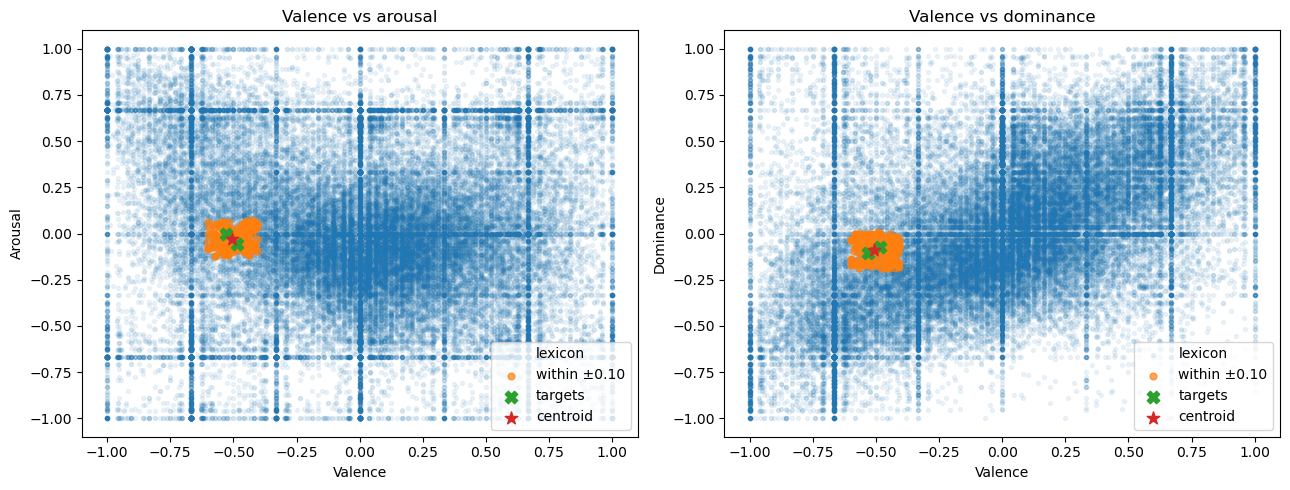

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(
    lexicon["valence"],
    lexicon["arousal"],
    s=8,
    alpha=0.08,
    label="lexicon",
)
axes[0].scatter(
    broad_candidates["valence"],
    broad_candidates["arousal"],
    s=24,
    alpha=0.7,
    label="within ±0.10",
)
axes[0].scatter(
    target_profile["valence"],
    target_profile["arousal"],
    s=80,
    marker="X",
    label="targets",
)
axes[0].scatter(
    [target_centroid["valence"]],
    [target_centroid["arousal"]],
    s=90,
    marker="*",
    label="centroid",
)
axes[0].set_title("Valence vs arousal")
axes[0].set_xlabel("Valence")
axes[0].set_ylabel("Arousal")
axes[0].legend()

axes[1].scatter(
    lexicon["valence"],
    lexicon["dominance"],
    s=8,
    alpha=0.08,
    label="lexicon",
)
axes[1].scatter(
    broad_candidates["valence"],
    broad_candidates["dominance"],
    s=24,
    alpha=0.7,
    label="within ±0.10",
)
axes[1].scatter(
    target_profile["valence"],
    target_profile["dominance"],
    s=80,
    marker="X",
    label="targets",
)
axes[1].scatter(
    [target_centroid["valence"]],
    [target_centroid["dominance"]],
    s=90,
    marker="*",
    label="centroid",
)
axes[1].set_title("Valence vs dominance")
axes[1].set_xlabel("Valence")
axes[1].set_ylabel("Dominance")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Next substantive screen

A plausible next-stage control shortlist should be reviewed against additional criteria that VAD does not encode:

1. noun-like usage and comparable lexical role;
2. non-clinical and non-therapy-speak status;
3. absence of obvious commercial, medical-list, or idiomatic contamination;
4. approximate frequency compatibility with `adhd` and `autism` in the same Common Crawl trend samples;
5. stability of that frequency relationship across years.

Only after that second screen should candidate terms be considered serious comparator replacements or additions.